In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.shape)
print(df.info())
print(df.describe())

(178, 14)
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target

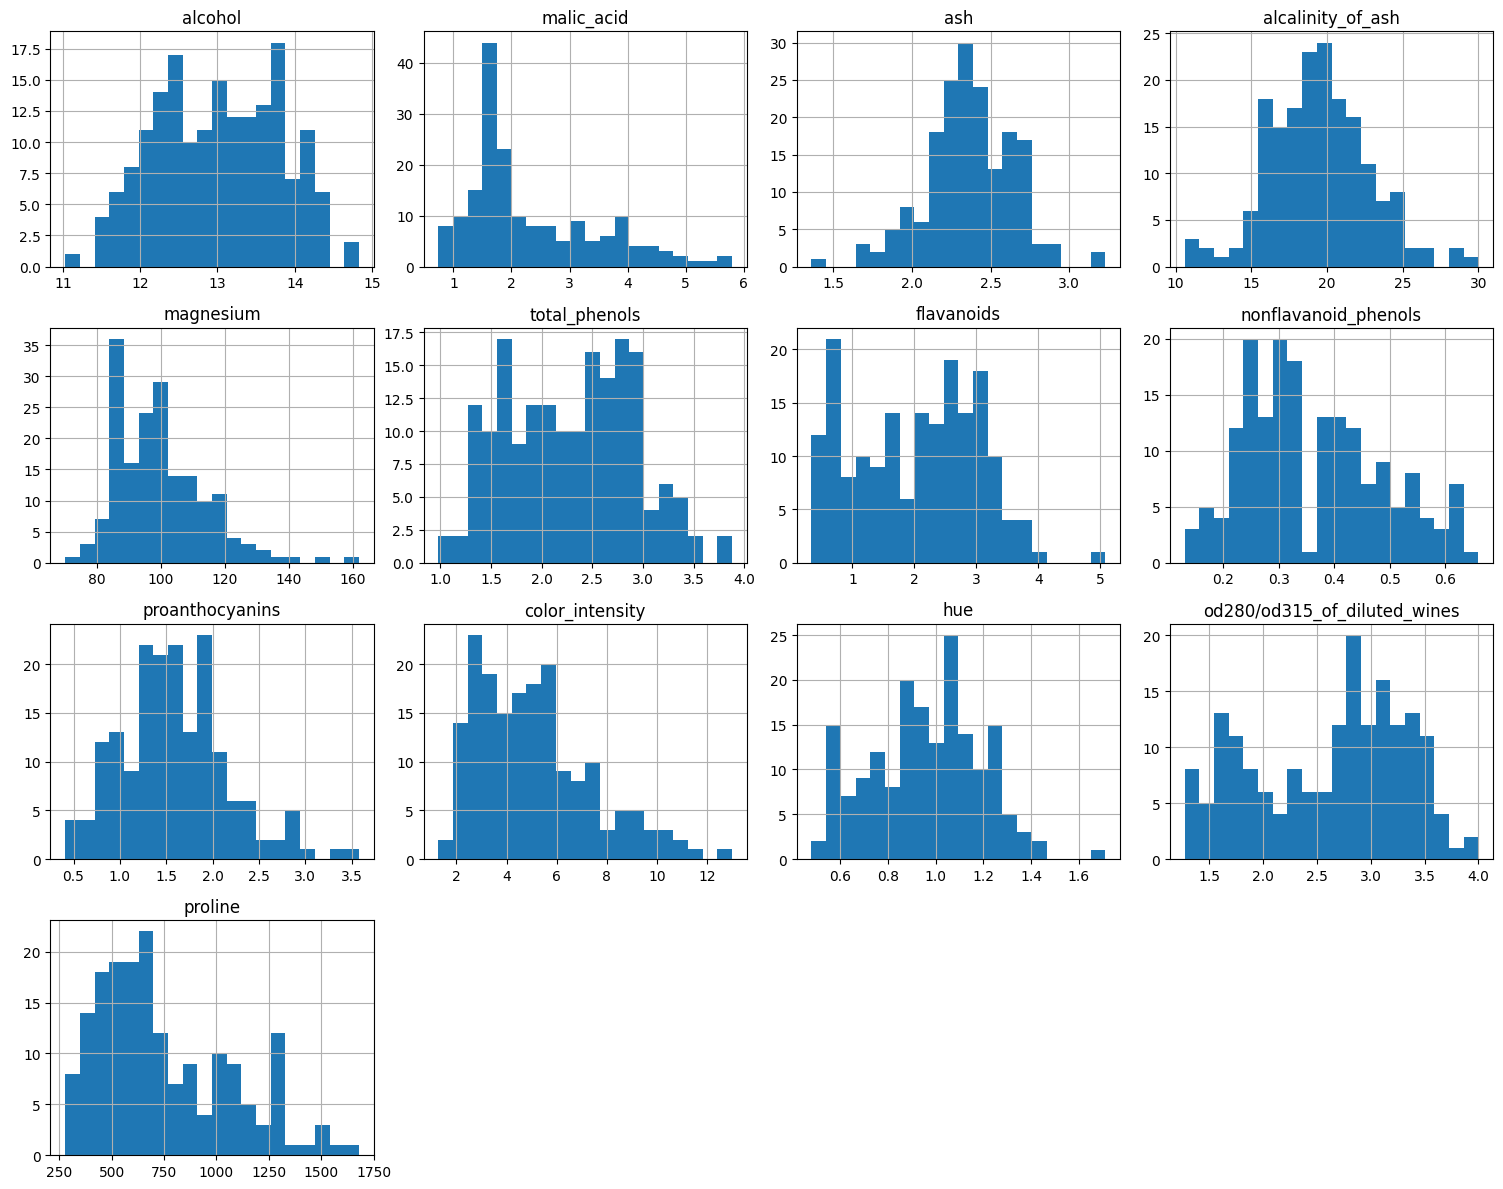

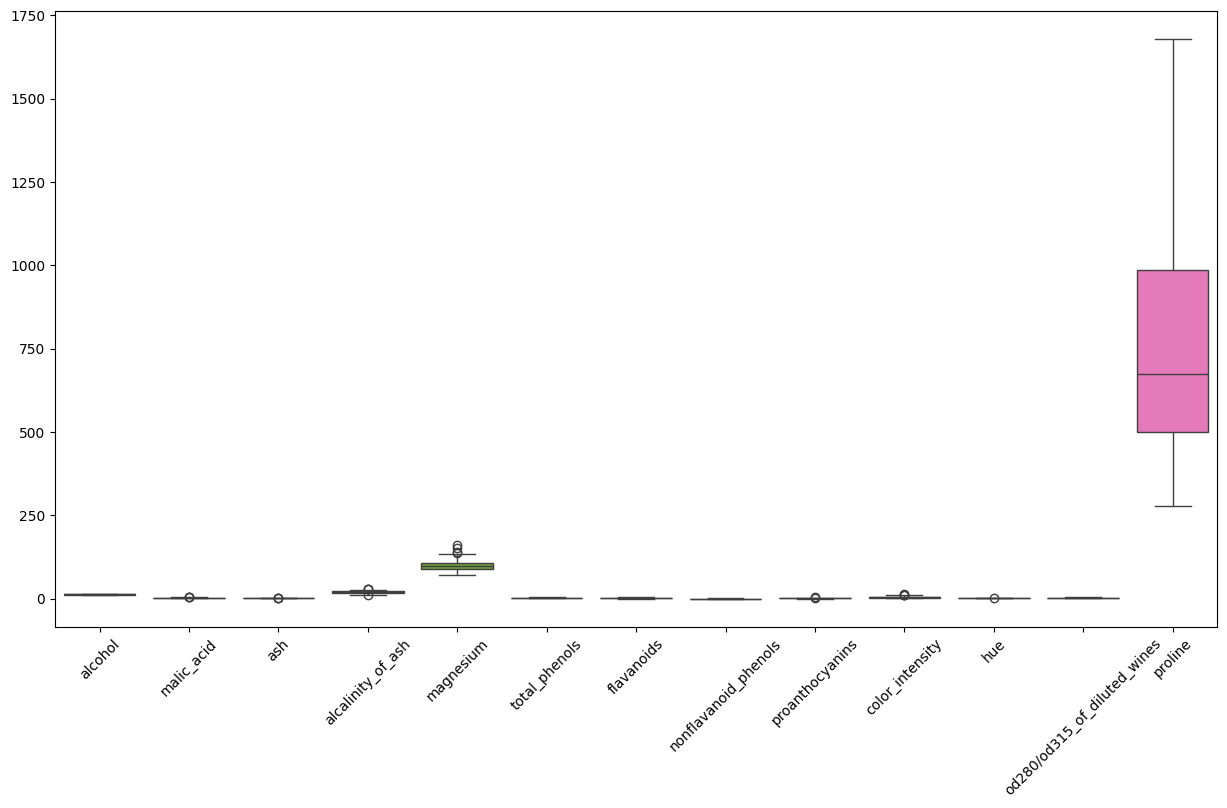

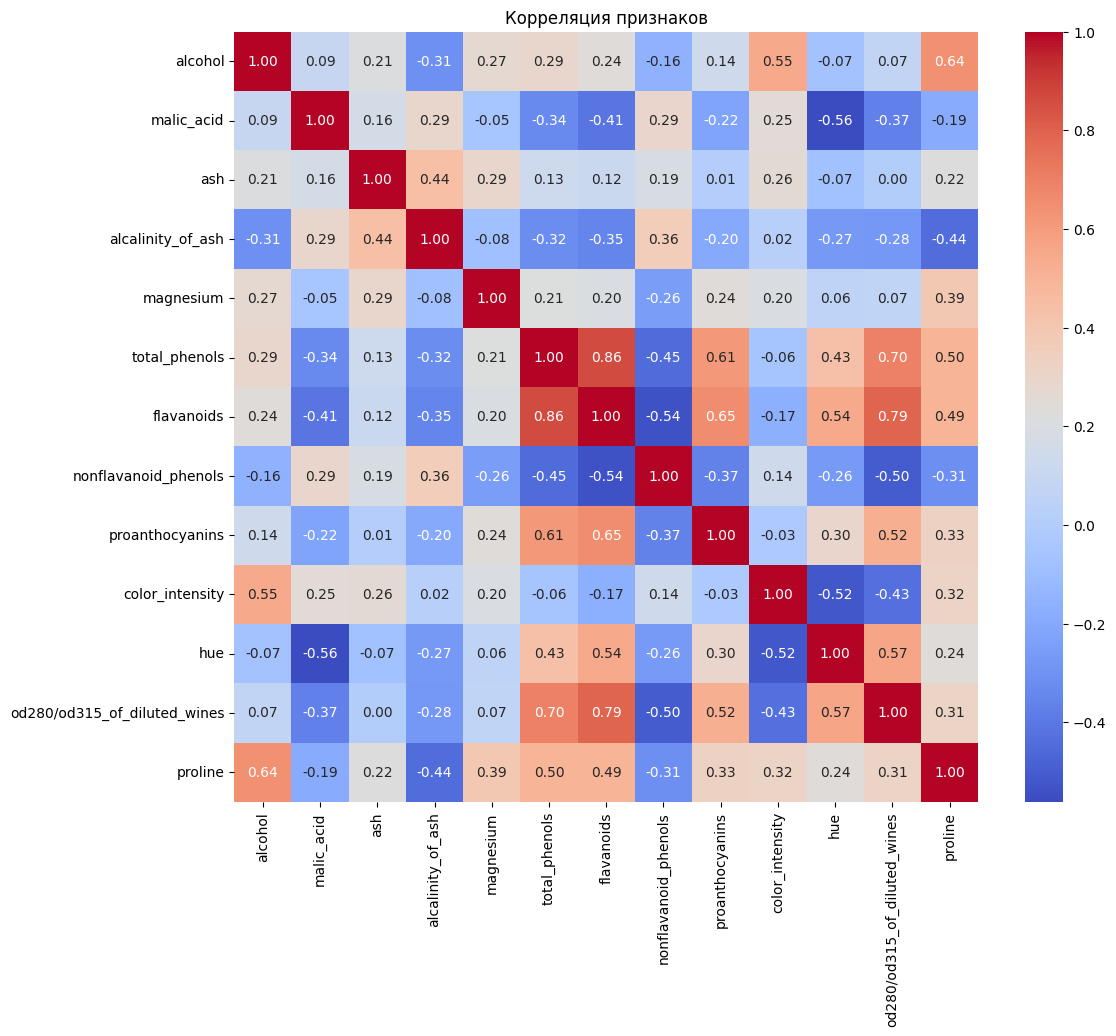

Тест Шапиро-Уилка для alcohol: p-value = 0.0200


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

df.iloc[:, :-1].hist(bins=20, figsize=(15,12))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,8))
sns.boxplot(data=df.iloc[:, :-1])
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,10))
corr = df.iloc[:, :-1].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

stat, p = shapiro(df['alcohol'])
print(f'Тест Шапиро-Уилка для alcohol: p-value = {p:.4f}')

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :-1])
y = df['target']

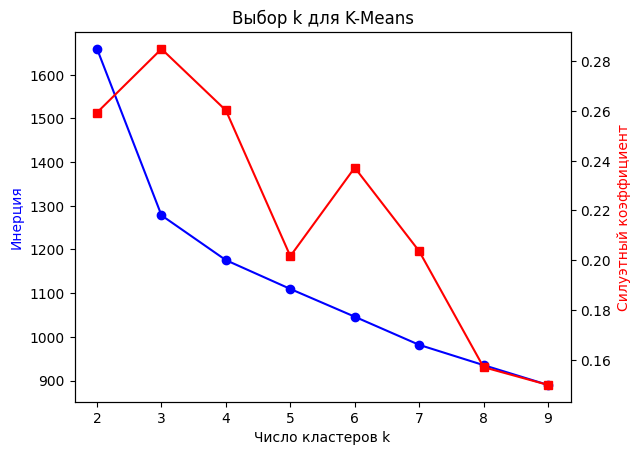

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(K_range, inertia, 'bo-')
ax2.plot(K_range, sil_scores, 'rs-')
ax1.set_xlabel('Число кластеров k')
ax1.set_ylabel('Инерция', color='b')
ax2.set_ylabel('Силуэтный коэффициент', color='r')
plt.title('Выбор k для K-Means')
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

In [6]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
clusters_agg = agg.fit_predict(X_scaled)

In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

n_noise = list(clusters_dbscan).count(-1)
print(f'DBSCAN выделил {n_noise} шумовых точек')

DBSCAN выделил 178 шумовых точек


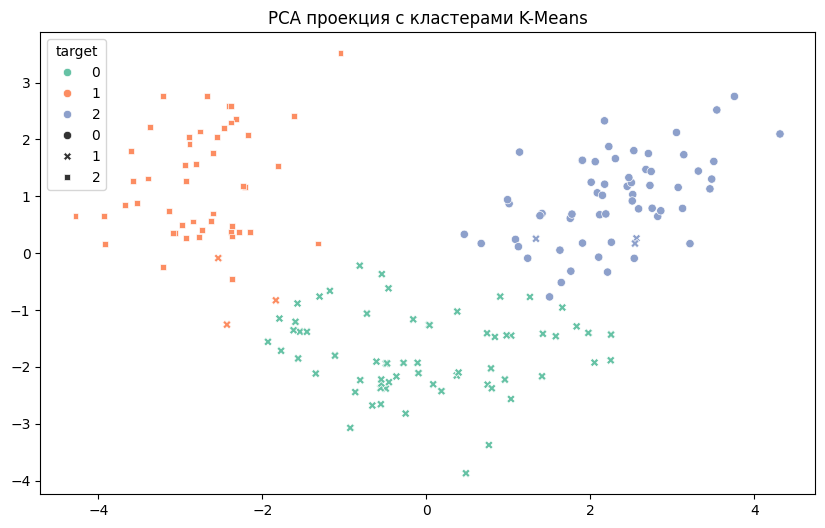

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_kmeans, palette='Set2', style=y)
plt.title('PCA проекция с кластерами K-Means')
plt.show()

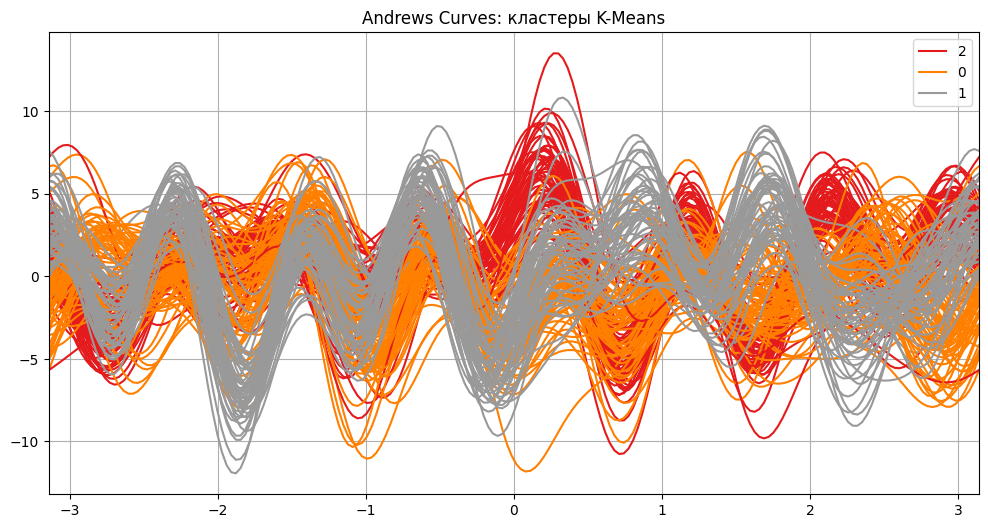

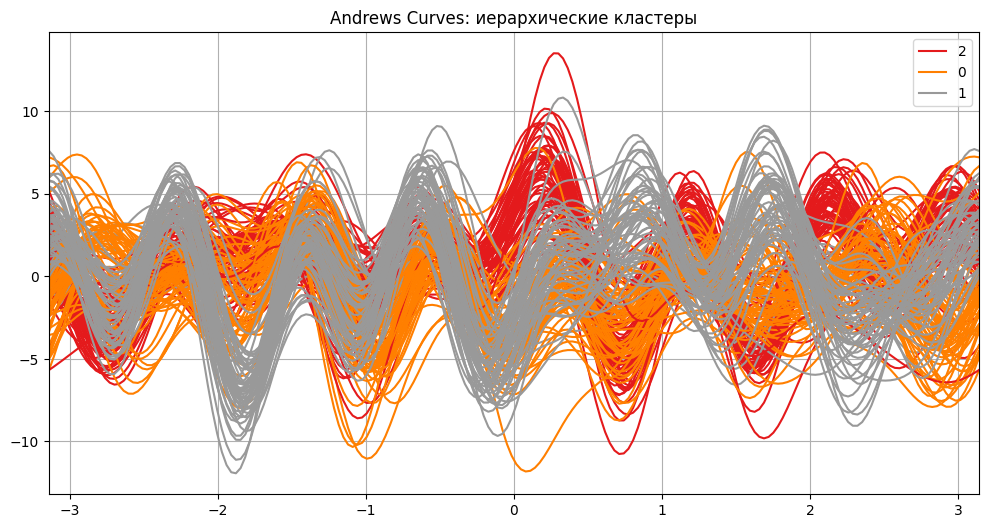

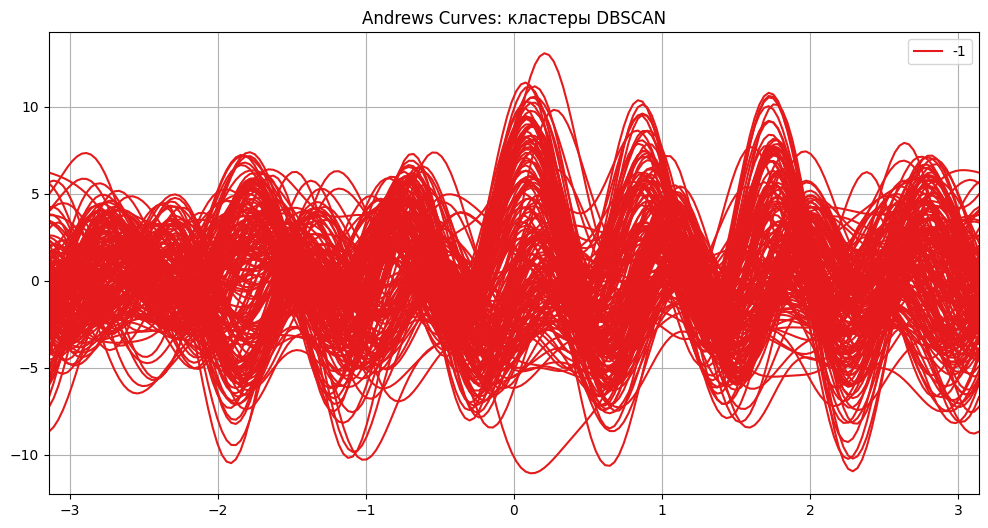

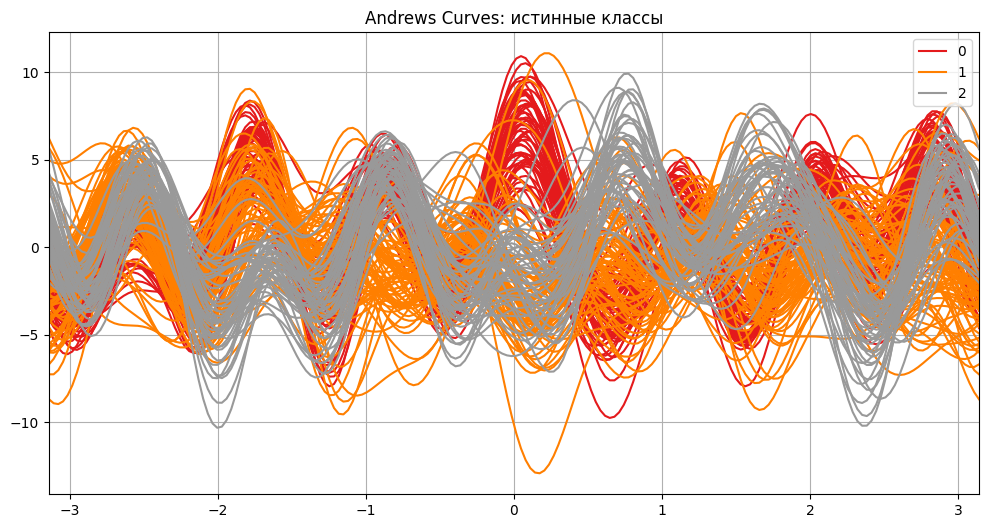

In [9]:
from pandas.plotting import andrews_curves

df_viz = pd.DataFrame(X_scaled, columns=data.feature_names)
df_viz['cluster_kmeans'] = clusters_kmeans
df_viz['cluster_agg'] = clusters_agg
df_viz['cluster_dbscan'] = clusters_dbscan
df_viz['true_class'] = y

plt.figure(figsize=(12,6))
andrews_curves(df_viz, 'cluster_kmeans', colormap='Set1')
plt.title('Andrews Curves: кластеры K-Means')
plt.show()

plt.figure(figsize=(12,6))
andrews_curves(df_viz, 'cluster_agg', colormap='Set1')
plt.title('Andrews Curves: иерархические кластеры')
plt.show()

plt.figure(figsize=(12,6))
andrews_curves(df_viz, 'cluster_dbscan', colormap='Set1')
plt.title('Andrews Curves: кластеры DBSCAN')
plt.show()

plt.figure(figsize=(12,6))
andrews_curves(df_viz, 'true_class', colormap='Set1')
plt.title('Andrews Curves: истинные классы')
plt.show()

In [10]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

models = {'K-Means': clusters_kmeans, 'Agglomerative': clusters_agg, 'DBSCAN': clusters_dbscan}
for name, pred in models.items():
    ari = adjusted_rand_score(y, pred)
    nmi = normalized_mutual_info_score(y, pred, average_method='arithmetic')
    print(f'{name}: ARI={ari:.3f}, NMI={nmi:.3f}')

K-Means: ARI=0.897, NMI=0.876
Agglomerative: ARI=0.790, NMI=0.786
DBSCAN: ARI=0.000, NMI=0.000


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models_clf = {
    'LogisticRegression': LogisticRegression(max_iter=10000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models_clf.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f'{name}: Accuracy={acc:.3f}, F1={f1:.3f}')

results_df = pd.DataFrame(results).T
print(results_df)

LogisticRegression: Accuracy=0.972, F1=0.971
KNN: Accuracy=0.972, F1=0.972
DecisionTree: Accuracy=0.944, F1=0.946
RandomForest: Accuracy=1.000, F1=1.000
                    Accuracy  Precision    Recall        F1
LogisticRegression  0.972222   0.977778  0.966667  0.970962
KNN                 0.972222   0.969697  0.976190  0.971781
DecisionTree        0.944444   0.958333  0.938889  0.945741
RandomForest        1.000000   1.000000  1.000000  1.000000


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, y_pred_best))

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV F1: 0.9863203463203462
Test Accuracy: 1.0


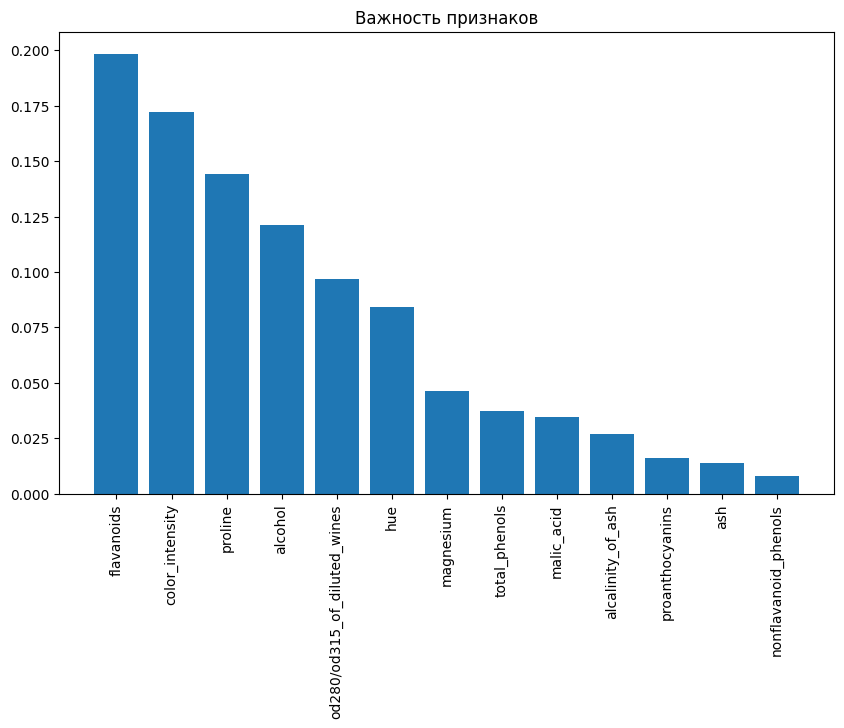

In [14]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), [data.feature_names[i] for i in indices], rotation=90)
plt.title('Важность признаков')
plt.show()

top_features = indices[:8]
X_train_sel = X_train[:, top_features]
X_test_sel = X_test[:, top_features]

In [15]:
lr_sel = LogisticRegression(penalty='l2', C=0.5, max_iter=1000, random_state=42)
lr_sel.fit(X_train_sel, y_train)
y_pred_lr_sel = lr_sel.predict(X_test_sel)
print('LR with selection: Accuracy', accuracy_score(y_test, y_pred_lr_sel))

LR with selection: Accuracy 1.0


c:\Dev\repo\Polytech\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', best_rf),
    ('knn', KNeighborsClassifier(n_neighbors=5))
], voting='soft')
voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)
print('Voting Accuracy:', accuracy_score(y_test, y_pred_vote))

Voting Accuracy: 1.0


In [17]:
final_models = {
    'Logistic Regression (all)': LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train),
    'KNN (all)': KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train),
    'Random Forest (tuned)': best_rf,
    'Logistic Reg. (selected)': lr_sel,
    'Voting Ensemble': voting
}

metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
for name, model in final_models.items():
    if 'selected' in name:
        pred = model.predict(X_test_sel)
    else:
        pred = model.predict(X_test)
    metrics['Accuracy'].append(accuracy_score(y_test, pred))
    metrics['Precision'].append(precision_score(y_test, pred, average='macro'))
    metrics['Recall'].append(recall_score(y_test, pred, average='macro'))
    metrics['F1'].append(f1_score(y_test, pred, average='macro'))

final_df = pd.DataFrame(metrics, index=list(final_models.keys()))
print(final_df)

                           Accuracy  Precision    Recall        F1
Logistic Regression (all)  0.972222   0.977778  0.966667  0.970962
KNN (all)                  0.972222   0.969697  0.976190  0.971781
Random Forest (tuned)      1.000000   1.000000  1.000000  1.000000
Logistic Reg. (selected)   1.000000   1.000000  1.000000  1.000000
Voting Ensemble            1.000000   1.000000  1.000000  1.000000


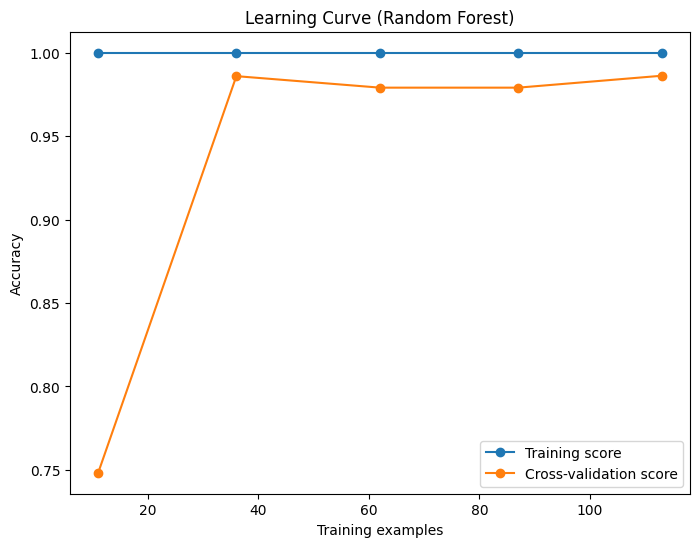

In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curve (Random Forest)')
plt.show()